# Motivation for Convolutional Neural Networks: MLP vs CNN on MNIST

**Author:** Phabel Antonio López Delgado, BSc.

This notebook motivates the use of **Convolutional Neural Networks (CNNs)** by comparing a simple Multi‑Layer Perceptron (MLP) with a CNN on the MNIST handwritten digit dataset. We observe that even a plain MLP can achieve high accuracy on MNIST due to its simplicity, but we also discuss the limitations of dense networks for more complex image tasks.

**Key Concepts Covered:**
- MNIST dataset: 60,000 training and 10,000 test images of handwritten digits (28×28 grayscale).
- Data preprocessing: normalisation, one‑hot encoding.
- MLP architecture: flattened input → dense layers with dropout.
- CNN architecture: convolutional layers, pooling, dense layers.
- Training and evaluation.
- Discussion: why MLP works on MNIST, but CNNs are needed for larger, more complex images.

**Key Techniques & Libraries:**
- `tensorflow.keras` – building and training models.
- `matplotlib` – visualisation.
- `numpy` – numerical operations.

**Objective:**
To understand the limitations of fully‑connected networks for image processing and to appreciate the spatial feature extraction capabilities of CNNs.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical

print("All imports successful.")

All imports successful.


## 1. Data Loading

We load the MNIST dataset, which contains 60,000 training and 10,000 test images of handwritten digits (0-9). Each image is 28×28 pixels in grayscale.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f"Training images: {len(X_train)}")
print(f"Test images: {len(X_test)}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: 60000
Test images: 10000


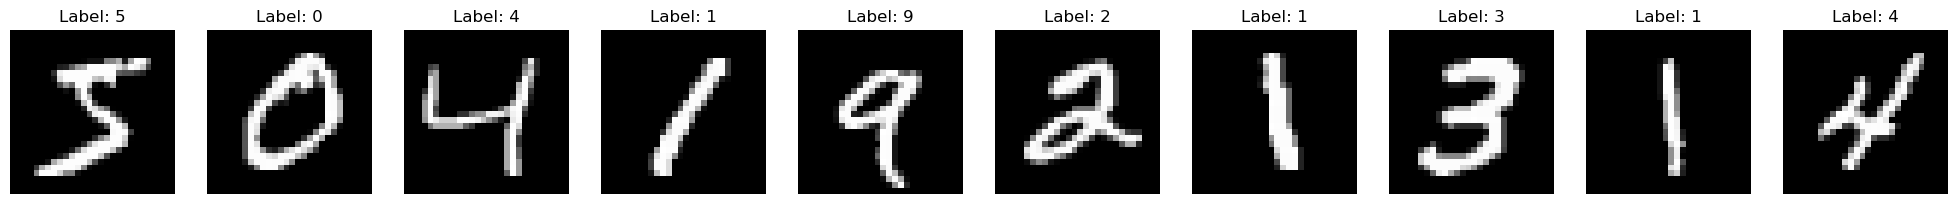

In [3]:
sample_count = 10
plt.figure(figsize=(25, 5))
for i in range(sample_count):
    ax = plt.subplot(1, sample_count, i + 1)
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

### Zoom into a Single Image

We display the pixel values of one image to see what a computer "sees".

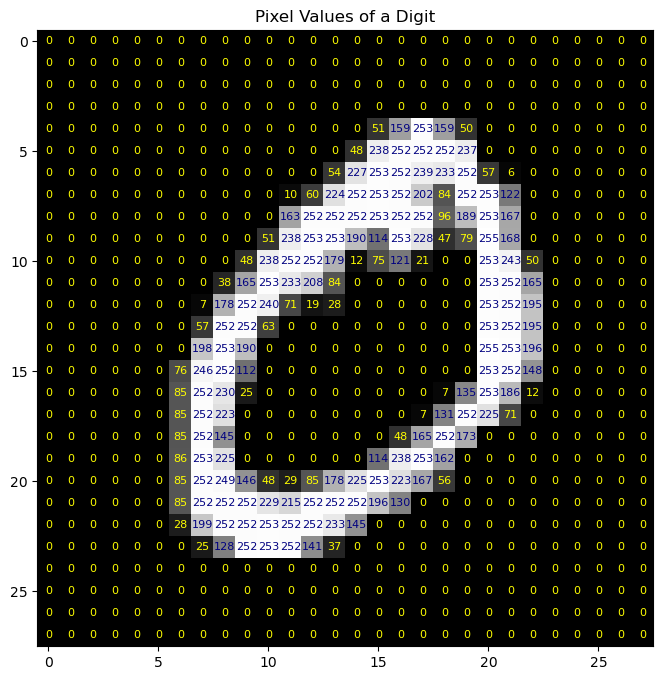

In [4]:
def visualize_pixels(image, ax):
    ax.imshow(image, cmap='gray')
    width, height = image.shape
    threshold = image.max() / 2.5
    for x in range(width):
        for y in range(height):
            pixel_value = image[x, y]
            ax.annotate(f'{pixel_value:.0f}',
                        xy=(y, x),
                        ha='center', va='center',
                        color='yellow' if pixel_value < threshold else 'navy',
                        fontsize=8)

sample_idx = 1
fig, ax = plt.subplots(figsize=(8, 8))
visualize_pixels(X_train[sample_idx], ax)
ax.set_title("Pixel Values of a Digit")
plt.show()

## 2. Data Preprocessing

We normalise pixel values to [0,1] and convert labels to one‑hot encoded vectors for multiclass classification.

In [5]:
# Normalise pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One‑hot encode labels
num_classes = 10
y_train_onehot = to_categorical(y_train, num_classes)
y_test_onehot = to_categorical(y_test, num_classes)

print("Original labels (first 10):", y_train[:10])
print("One‑hot encoded (first 10):\n", y_train_onehot[:10])

Original labels (first 10): [5 0 4 1 9 2 1 3 1 4]
One‑hot encoded (first 10):
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


## 3. Model 1: Multi‑Layer Perceptron (MLP)

We build a simple dense network that flattens the 28×28 images into a 784‑element vector. This ignores spatial structure, which is a key limitation for image data.

In [6]:
mlp = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

mlp.summary()

C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ flatten (Flatten)            │ (None, 784)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 512)           │     401,920 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout (Dropout)            │ (None, 512)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_1 (Dense)              │ (None, 512)           │     262,656 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_1 (Dropout)          │ (None, 512)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_2 (Dense)              │ (None, 10)            │       5,130 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 669,706 (2.55 MB)

 Trainable params: 669,706 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Model 2: Convolutional Neural Network (CNN)

We design a CNN with two convolutional layers (with ReLU activation), pooling layers, and then dense layers. This model preserves and learns spatial features.

In [7]:
# Reshape data for CNN: add channel dimension (grayscale)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

cnn.summary()

C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ conv2d (Conv2D)              │ (None, 26, 26, 32)    │         320 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ max_pooling2d (MaxPooling2D) │ (None, 13, 13, 32)    │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ conv2d_1 (Conv2D)            │ (None, 11, 11, 64)    │      18,496 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ max_pooling2d_1              │ (None, 5, 5, 64)      │           0 │
│ (MaxPooling2D)               │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ flatten_1 (Flatten)          │ (None, 1600)          │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_3 (Dense)              │ (None, 512)           │     819,712 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_2 (Dropout)          │ (None, 512)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_4 (Dense)              │ (None, 512)           │     262,656 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_3 (Dropout)          │ (None, 512)           │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_5 (Dense)              │ (None, 10)            │       5,130 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 1,106,314 (4.22 MB)

 Trainable params: 1,106,314 (4.22 MB)

 Non-trainable params: 0 (0.00 B)

### Comparison of Parameter Counts

- **MLP**: ~669k trainable parameters.
- **CNN**: ~1.1M trainable parameters (but it learns spatial hierarchies).

Note: The CNN has more parameters, but it is more efficient for images because it uses shared weights (filters) and pooling to reduce spatial dimensions.

## 5. Training the MLP

We train the MLP for 10 epochs with a batch size of 256. We use a validation split of 20% and save the best model.

In [8]:
mlp.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

# Create checkpoint directory
os.makedirs('models', exist_ok=True)
checkpoint_path = 'models/mlp_mnist.keras'
checkpointer = ModelCheckpoint(filepath=checkpoint_path, save_best_only=True)

history_mlp = mlp.fit(X_train, y_train_onehot,
                      batch_size=256,
                      validation_split=0.2,
                      epochs=10,
                      callbacks=[checkpointer],
                      shuffle=True)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8994 - loss: 0.3390 - val_accuracy: 0.9603 - val_loss: 0.1352
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9617 - loss: 0.1260 - val_accuracy: 0.9707 - val_loss: 0.0961
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9739 - loss: 0.0843 - val_accuracy: 0.9748 - val_loss: 0.0814
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9808 - loss: 0.0631 - val_accuracy: 0.9762 - val_loss: 0.0782
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9849 - loss: 0.0487 - val_accuracy: 0.9757 - val_loss: 0.0841
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9870 - loss: 0.0421 - val_accuracy: 0.9753 - val_loss: 0.0841
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9886 - loss: 0.0344 - val_accuracy: 0.9771 - val_loss: 0.0820
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9911 - loss: 0.0269 - val_accuracy: 0.

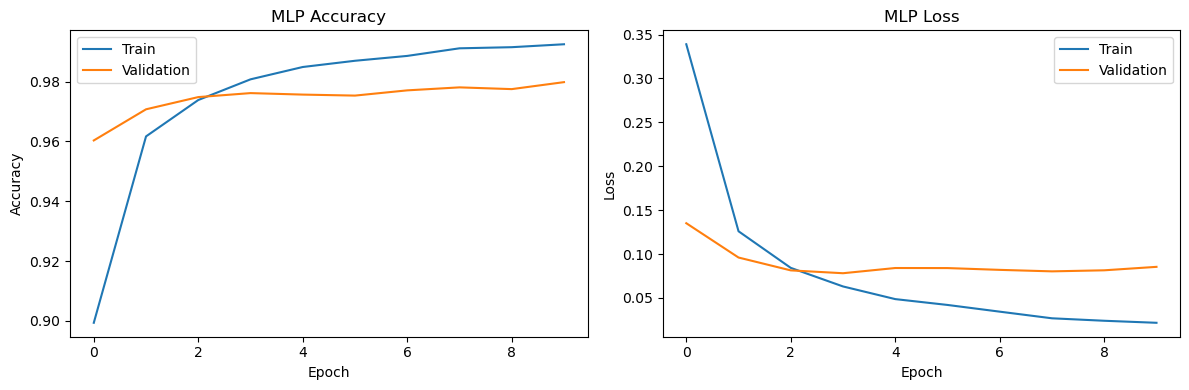

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='Train')
plt.plot(history_mlp.history['val_accuracy'], label='Validation')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='Train')
plt.plot(history_mlp.history['val_loss'], label='Validation')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
mlp.load_weights(checkpoint_path)
mlp_score = mlp.evaluate(X_test, y_test_onehot, verbose=0)
print(f"MLP Test Accuracy: {mlp_score[1] * 100:.2f}%")
print(f"MLP Test Loss: {mlp_score[0]:.4f}")

MLP Test Accuracy: 97.69%
MLP Test Loss: 0.0700


## 6. Training the CNN

We train the CNN under the same conditions (10 epochs, batch size 256, 20% validation split).

In [11]:
cnn.compile(optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy'])

checkpoint_cnn = 'models/cnn_mnist.keras'
checkpointer_cnn = ModelCheckpoint(filepath=checkpoint_cnn, save_best_only=True)

history_cnn = cnn.fit(X_train_cnn, y_train_onehot,
                      batch_size=256,
                      validation_split=0.2,
                      epochs=10,
                      callbacks=[checkpointer_cnn],
                      shuffle=True)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.9144 - loss: 0.2757 - val_accuracy: 0.9810 - val_loss: 0.0651
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9801 - loss: 0.0641 - val_accuracy: 0.9850 - val_loss: 0.0504
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9871 - val_loss: 0.0431
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9893 - loss: 0.0334 - val_accuracy: 0.9884 - val_loss: 0.0396
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9914 - val_loss: 0.0350
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9936 - loss: 0.0186 - val_accuracy: 0.9892 - val_loss: 0.0380
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9949 - loss: 0.0160 - val_accuracy: 0.9898 - val_loss: 0.0389
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9956 - loss: 0.0136 - val_accu

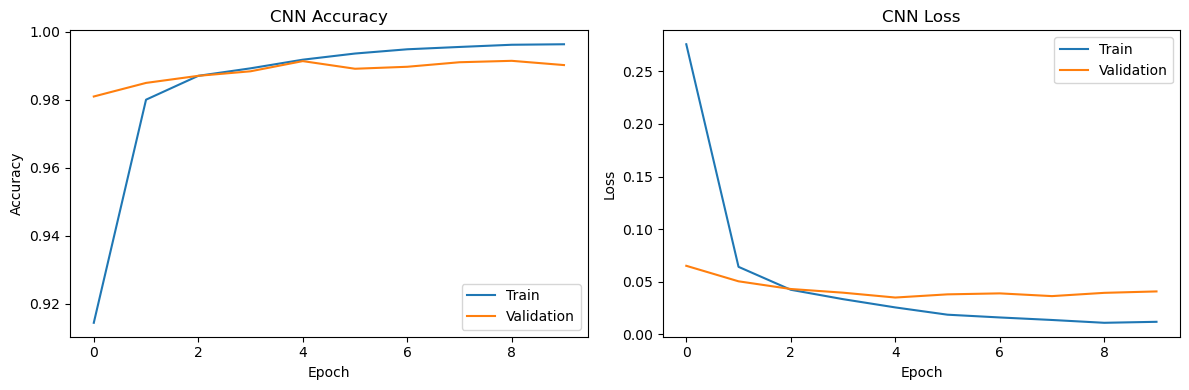

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train')
plt.plot(history_cnn.history['val_accuracy'], label='Validation')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train')
plt.plot(history_cnn.history['val_loss'], label='Validation')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
cnn.load_weights(checkpoint_cnn)
cnn_score = cnn.evaluate(X_test_cnn, y_test_onehot, verbose=0)
print(f"CNN Test Accuracy: {cnn_score[1] * 100:.2f}%")
print(f"CNN Test Loss: {cnn_score[0]:.4f}")

CNN Test Accuracy: 99.07%
CNN Test Loss: 0.0288


## 7. Discussion: Why Does the MLP Work Well on MNIST?

Despite the limitations of dense networks for images, the MLP achieved **97.69%** accuracy on MNIST. This is because:

1. **Small number of classes** – only 10 digits.
2. **Low resolution** – 28×28 pixels, so the flattened vector (784) is not too large.
3. **Digits are centred** – they are roughly aligned in the middle of the image.
4. **Grayscale** – only one colour channel, simplifying the task.
5. **Consistent size** – all digits are approximately the same scale.

However, for more complex datasets like CIFAR‑10 (colour, 32×32, objects with varying positions), a plain MLP would fail due to:

- **Lack of translation invariance** – no weight sharing.
- **Spatial structure ignored** – pixel positions are not preserved.
- **Scalability** – parameter count grows quadratically with input size.

These limitations motivate the use of **Convolutional Neural Networks**, which:
- Learn local features (filters) that are shared across the image.
- Preserve spatial relationships.
- Are more parameter‑efficient and generalise better to complex visual tasks.

---

**Comparison Summary:**

| Model | Test Accuracy | Parameters | Comments |
|-------|---------------|------------|----------|
| MLP   | 97.69%        | 669,706    | Good on MNIST; limited for larger images |
| CNN   | 99.07%        | 1,106,314  | Better on MNIST; essential for complex images |

The CNN outperforms the MLP by **1.38 percentage points** on this simple dataset. For more challenging datasets, the gap would be much larger.

## Summary and Next Steps

**Accomplished:**
- Built and evaluated both an MLP and a CNN on the MNIST dataset.
- Observed that both achieve high accuracy, with the CNN outperforming the MLP (99.07% vs 97.69%).
- Discussed the limitations of dense networks for image processing.
- Understood the motivation for using CNNs: local feature extraction, parameter sharing, and preservation of spatial structure.

**Key Results:**
- MLP Test Accuracy: **97.69%**
- CNN Test Accuracy: **99.07%**
- MLP Parameters: 669,706
- CNN Parameters: 1,106,314

**Key Insights:**
- MLPs can work well on small, clean, centred datasets like MNIST.
- CNNs are more powerful and scalable for real‑world image tasks.
- The spatial structure of images is crucial; flattening loses this information.
- CNNs use shared weights (filters) which makes them parameter‑efficient for images.
- Despite having more parameters, the CNN learns spatial hierarchies more effectively.

**Suggested Next Steps:**
1. **Apply CNN to a more complex dataset** – e.g., CIFAR‑10, Fashion‑MNIST, or a custom image dataset.
2. **Visualise the learned filters** – inspect what features the CNN is learning in each layer.
3. **Experiment with different CNN architectures** – add more layers, vary filter sizes, use batch normalisation, or try different activation functions.
4. **Use data augmentation** – improve generalisation by generating more training samples (rotation, flipping, zoom).
5. **Compare with pre‑trained models** – use transfer learning with a model like ResNet or VGG on a larger dataset.
6. **Explore different optimisers** – compare Adam, SGD, RMSprop, and others.
7. **Hyperparameter tuning** – experiment with learning rate, batch size, number of epochs, and dropout rates.

**Reflection:**
This notebook clearly demonstrates the strengths and weaknesses of MLPs versus CNNs for image classification. The high performance of the MLP on MNIST should not mislead us into thinking dense networks are sufficient for vision tasks; the CNN's ability to learn spatial hierarchies makes it the go‑to choice for modern computer vision. The small gap on MNIST (1.38%) illustrates why MNIST is often considered a "solved" problem, but the architectural advantages of CNNs become critical when scaling to more complex, real‑world image datasets.